In [1]:
import pandas as pd

#### Get the flood dataset

In [2]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,1001,2000,ALABAMA,AUTAUGA,1,200000.0,3.50
1,1001,2001,ALABAMA,AUTAUGA,2,37000.0,4.25
2,1001,2003,ALABAMA,AUTAUGA,2,58000.0,6.00
3,1001,2004,ALABAMA,AUTAUGA,1,8000.0,3.50
4,1001,2005,ALABAMA,AUTAUGA,6,19000.0,76.00
...,...,...,...,...,...,...,...
35445,56045,2012,WYOMING,WESTON,1,5000.0,1.00
35446,56045,2013,WYOMING,WESTON,3,135000.0,8.33
35447,56045,2015,WYOMING,WESTON,4,30000.0,37.08
35448,56045,2018,WYOMING,WESTON,1,0.0,40.08


#### Get the HPI dataset

In [3]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()

,cbsa_code,cbsa_title,county_fips5,county/county_equivalent,state_name,place_name,place_id,yr,index_nsa,index_prev,hpi_change,hpi_yoy
13755,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2000,114.6775,113.7350,0.9425,0.828681
13756,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2001,119.9250,114.6775,5.2475,4.575876
13757,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2002,122.0075,119.9250,2.0825,1.736502
13758,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2003,125.8200,122.0075,3.8125,3.124808
13759,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2004,129.5400,125.8200,3.7200,2.956605
...,...,...,...,...,...,...,...,...,...,...,...,...
3124,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2016,273.0800,278.0150,-4.9350,-1.775084
3125,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2017,269.6775,273.0800,-3.4025,-1.245972
3126,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2018,273.1500,269.6775,3.4725,1.287649
3127,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2019,280.6300,273.1500,7.4800,2.738422


#### Checking for missing counties

In [4]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [5]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56025)

In [6]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2170, 41031,  9120,  9190,  2090,  9110,  9130, 15005,  9170,
        9180, 53059, 13173,  9140])

In [7]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1005,  1011,  1013, ..., 56041, 56043, 56045], shape=(2115,))

#### Merge flood and HPI datasets

In [8]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="inner",
)
hpi_flood  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20
...,...,...,...,...,...,...,...,...,...,...
12945,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50
12946,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00
12947,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00
12948,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83


In [9]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["FIPS", "YEAR"])
    .reset_index()
    .sort_values(by=["FIPS", "YEAR"])
)
temp[temp["count"] > 1]

,FIPS,YEAR,count


#### Get heat dataset

In [10]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [11]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [12]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [13]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [14]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["FIPS", "YEAR"],
    right_on=["FIPS", "year"],
    how="inner",
)
hpi_flood_heat  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,year,value,heat_index,HSI
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08,2002,90.8,0.059089,0.323792
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00,2003,92.8,0.178862,0.442478
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18,2004,89.6,-0.000561,0.413233
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02,2005,91.3,0.098956,0.344927
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20,2007,87.9,-0.029850,0.220479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12904,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50,2014,105.0,0.336505,0.863331
12905,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00,2015,105.8,0.383922,0.838107
12906,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00,2016,106.9,0.414770,0.872492
12907,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83,2018,106.4,0.402691,0.818690


In [15]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Get the drought and wildfire datasets

In [16]:
# MERGED TWICE TO REMOVE DUPLICATES

wildfire_drought = pd.read_csv(
    "../../02_processed_data/merged_wildfire_drought.csv"
).reset_index(drop=True)
wildfire_drought

,FIPS,Year,County,State_ncei,State_abbr,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,State_fire
0,1001,2003,Autauga County,Alabama,AL,2.39,43,274.80,AL
1,1001,2004,Autauga County,Alabama,AL,0.00,86,744.50,AL
2,1001,2005,Autauga County,Alabama,AL,0.90,63,234.20,AL
3,1001,2006,Autauga County,Alabama,AL,-1.34,62,534.70,AL
4,1001,2007,Autauga County,Alabama,AL,-3.33,93,477.30,AL
...,...,...,...,...,...,...,...,...,...
41622,56045,2016,Weston County,Wyoming,WY,-2.27,34,2775.14,WY
41623,56045,2017,Weston County,Wyoming,WY,-1.32,33,96.40,WY
41624,56045,2018,Weston County,Wyoming,WY,4.41,15,96.90,WY
41625,56045,2019,Weston County,Wyoming,WY,7.09,13,93.05,WY


In [17]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought.value_counts(subset=["FIPS", "Year"])
    .reset_index()
    .sort_values(by=["FIPS", "Year"])
)
temp[temp["count"] > 1]

,FIPS,Year,count


#### Merge Drought/Wildfire/HPI/Flood/Heat dataset

In [18]:
wildfire_drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    wildfire_drought,
    left_on=["FIPS", "YEAR"],
    right_on=["FIPS", "Year"],
    how="inner",
)
wildfire_drought_hpi_flood_heat.head()  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,...,heat_index,HSI,Year,County,State_ncei,State_abbr,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,State_fire
0,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00,...,0.178862,0.442478,2003,Callahan County,Texas,TX,0.96,1,100.00,TX
1,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18,...,-0.000561,0.413233,2004,Callahan County,Texas,TX,2.28,19,61.00,TX
2,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02,...,0.098956,0.344927,2005,Callahan County,Texas,TX,1.93,16,10011.00,TX
3,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20,...,-0.029850,0.220479,2007,Callahan County,Texas,TX,1.30,14,489.00,TX
4,48059,2012,1.612448,48059,2012,TEXAS,CALLAHAN,1,0.0,6.00,...,0.353297,0.507034,2012,Callahan County,Texas,TX,-1.76,54,89.56,TX


In [19]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["FIPS", "Year"])
    .reset_index()
    .sort_values(by=["FIPS", "Year"])
)
temp[temp["count"] > 1]

,FIPS,Year,count


In [ ]:
wildfire_drought_hpi_flood_heat.value_counts

#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [35]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [34]:
wildfire_drought_hpi_flood_heat_huricane = wildfire_drought_hpi_flood_heat.merge(
    huricane_grouped, left_on=["FIPS", "YEAR"], right_on=["FIPS", "year"], how="inner"
)

# # sanity checks
# print(hpi_flood_heat.shape, storm2.shape, hpi_flood_heat_joined.shape)
# print(
#     "Left dups:",
#     hfh2.duplicated(["FIPS", "YEAR"]).sum(),
#     "| Right dups:",
#     storm2.duplicated(["FIPS", "YEAR"]).sum(),
# )
wildfire_drought_hpi_flood_heat_huricane

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,...,State_ncei,State_abbr,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,State_fire,year_y,deaths_hurricane,injuries_hurricane,damage_hurricane
0,13095,2018,2.094798,13095,2018,GEORGIA,DOUGHERTY,3,0.0,6.28,...,Georgia,GA,0.54,12,71.41,GA,2018,0.0,0.0,411000000
1,13177,2005,5.926110,13177,2005,GEORGIA,LEE,12,0.0,3.28,...,Georgia,GA,1.82,38,86.14,GA,2005,0.0,0.0,100000
2,13177,2018,2.094798,13177,2018,GEORGIA,LEE,21,100000.0,15.98,...,Georgia,GA,0.73,6,7.32,GA,2018,0.0,0.0,116000000
3,13273,2005,5.926110,13273,2005,GEORGIA,TERRELL,2,300000.0,4.00,...,Georgia,GA,1.78,6,25.44,GA,2005,0.0,0.0,250000
4,13321,2005,5.926110,13321,2005,GEORGIA,WORTH,1,1750000.0,8.00,...,Georgia,GA,1.34,50,144.84,GA,2005,0.0,0.0,1750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,37019,2018,6.374252,37019,2018,NORTH CAROLINA,BRUNSWICK,10,550000.0,34.85,...,North Carolina,NC,2.37,41,181.98,NC,2018,0.0,0.0,200000
119,37129,2016,4.587577,37129,2016,NORTH CAROLINA,NEW HANOVER,13,2305000.0,42.27,...,North Carolina,NC,3.79,15,21.43,NC,2016,0.0,0.0,0
120,37129,2018,6.374252,37129,2018,NORTH CAROLINA,NEW HANOVER,9,2350000.0,34.02,...,North Carolina,NC,4.73,2,0.75,NC,2018,1.0,1.0,1000000000
121,37141,2016,4.587577,37141,2016,NORTH CAROLINA,PENDER,13,925000.0,36.67,...,North Carolina,NC,4.19,27,37.62,NC,2016,0.0,0.0,0


## EDA on merged dataset

In [20]:
for_training = hpi_flood[
    [
        "FIPS",
        "hpi_yoy",
        "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
    ]
]
Y = for_training["hpi_yoy"]
X = for_training.drop(columns=["hpi_yoy"])  # ,"FIPS","YEAR"

In [21]:
from scipy.stats import pearsonr
import statsmodels.formula.api as smf

r, p = pearsonr(for_training["COUNT"], for_training["hpi_yoy"])
print(f"Pearson correlation (COUNT vs HPI YoY): r={r:.3f}, p={p:.4g}")
r, p = pearsonr(for_training["TOTAL_DAMAGE_PROPERTY"], for_training["hpi_yoy"])
print(f"Pearson correlation (TOTAL DAMAGE PROPERTY vs HPI YoY): r={r:.3f}, p={p:.4g}")
r, p = pearsonr(for_training["TOTAL_DURATION_HOURS"], for_training["hpi_yoy"])
print(f"Pearson correlation (TOTAL DURATION HOURS vs HPI YoY): r={r:.3f}, p={p:.4g}")

# # --- Panel Regression (time FE) ---
# # Model: HPI YoY ~ Risk Score + Year Fixed Effects
# model = smf.ols("hpi_yoy ~ COUNT + C(YEAR)", data=for_training).fit(
#     cov_type="cluster" , cov_kwds={"groups": for_training["FIPS"]}
# )

# print(model.summary().tables[1])  # coefficients table

Pearson correlation (COUNT vs HPI YoY): r=-0.011, p=0.2276
Pearson correlation (TOTAL DAMAGE PROPERTY vs HPI YoY): r=-0.001, p=0.9533
Pearson correlation (TOTAL DURATION HOURS vs HPI YoY): r=-0.014, p=0.1031


In [22]:
corr = X.corr(numeric_only=True)
print(corr)

                           FIPS      YEAR     COUNT  TOTAL_DAMAGE_PROPERTY  \
FIPS                   1.000000 -0.001030 -0.021902               0.021195   
YEAR                  -0.001030  1.000000  0.023079               0.027954   
COUNT                 -0.021902  0.023079  1.000000               0.017301   
TOTAL_DAMAGE_PROPERTY  0.021195  0.027954  0.017301               1.000000   
TOTAL_DURATION_HOURS  -0.035510  0.040398  0.112656               0.019525   

                       TOTAL_DURATION_HOURS  
FIPS                              -0.035510  
YEAR                               0.040398  
COUNT                              0.112656  
TOTAL_DAMAGE_PROPERTY              0.019525  
TOTAL_DURATION_HOURS               1.000000  


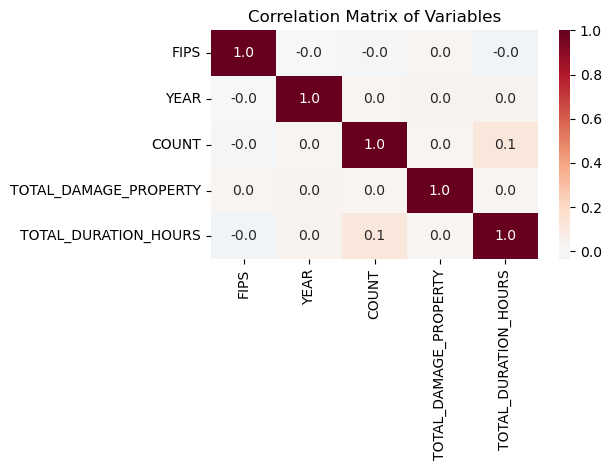

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()